# **Setup Game Environment:**

- pip install gym==0.21.0
- pip install gym gym-retro
- pip install importlib-metadata==4.13.0
- python -m retro.import . 

In [1]:
#import retro: to run the game disk
import retro
#import time: to slow down game render time
import time
from gym.spaces.space import Space

In [ ]:
#Setup game environment
env = retro.make(game='StreetFighterIISpecialChampionEdition-Genesis', use_restricted_actions = retro.Actions.FILTERED)

In [ ]:
#closes any running game environment
env.close()

# **Setup Learning environment for Training:**

Data Preprocessing the observed environment:
- Colour to grayscale
- Resize the frame for effeciency
- Calculate delta frame: change in subsequent frames
- Tweak the reward function

In [2]:
# Import environment base class for a wrapper
from gym import Env
# Import the space shapes for the environment
from gym.spaces import MultiBinary, Box
# Import numpy to calculate frame delta
import numpy as np
# Import opencv for grayscaling
import cv2
# Import matplotlib for plotting the image
from matplotlib import pyplot as plt

In [3]:
class StreetFighter(Env):
    def __init__(self):
        super().__init__()
        
        # Specify action and observation space
        self.observation_space = Box(low=0, high=255, shape=(149,256, 1), dtype=np.uint8)
        self.action_space = MultiBinary(12)
        # Startup an instance of the game
        self.game = retro.make(game='StreetFighterIISpecialChampionEdition-Genesis', use_restricted_actions=retro.Actions.FILTERED)
        

    def reset(self):
        self.previous_frame = np.zeros(self.game.observation_space.shape)
        
        # Reset the game and preprocess the first frame
        obs = self.preprocess(self.game.reset())
        self.previous_frame = obs
        self.score = 0
        
        # Reset agent and enemy health
        self.agent_health = 176
        self.enemy_health = 176
        self.previous_enemy_health = 176
        self.previous_agent_health = 176
        
        return obs

    def preprocess(self, observation):
        return np.reshape(cv2.resize(cv2.cvtColor(observation[41:190,0:256], cv2.COLOR_BGR2GRAY), (256, 149), interpolation=cv2.INTER_NEAREST), (149, 256, 1))

    def step(self, action):
        obs, reward, done, info = self.game.step(action)
        obs = self.preprocess(obs)
        frame_delta = obs

        # Update agent and enemy health
        self.agent_health = info['health']
        self.enemy_health = info['enemy_health']
        block_points = 0

        agent_health_delta = self.previous_agent_health - self.agent_health
        health_penalty = (agent_health_delta / 176.0) * 1000

        enemy_health_delta = self.previous_enemy_health - self.enemy_health
        damage_reward = (enemy_health_delta / 176.0 ) * 500 
        if(agent_health_delta == 0):
            damage_reward*=2

        if(agent_health_delta == 1):
            block_points = 200
            health_penalty = 0
        
        frame_score = info['score'] 

        reward = frame_score - self.score + damage_reward + block_points - health_penalty
        
        self.score = frame_score
        self.previous_enemy_health = self.enemy_health
        self.previous_agent_health = self.agent_health

        damage_reward = 0
        health_penalty = 0
        block_points = 0
        
        return frame_delta, reward, done, info

    def render(self, *args, **kwargs):
        self.game.render()

    def close(self):
        self.game.close()

In [3]:
class StreetFighter(Env):
    def __init__(self):
        super().__init__()
        self.observation_space = Box(low=0, high=255, shape=(149, 256, 1), dtype=np.uint8)
        self.action_space = MultiBinary(12)
        self.game = retro.make('StreetFighterIISpecialChampionEdition-Genesis', use_restricted_actions=retro.Actions.FILTERED)
        self.previous_frame = None
        self.score = 0
        self.agent_health = 176
        self.enemy_health = 176
        self.previous_enemy_health = 176
        self.previous_agent_health = 176

    def reset(self):
        obs = self.preprocess(self.game.reset())
        self.previous_frame = obs
        self.score = 0
        self.agent_health = 176
        self.enemy_health = 176
        self.previous_enemy_health = 176
        self.previous_agent_health = 176
        return obs

    def preprocess(self, observation):
        return np.reshape(cv2.resize(cv2.cvtColor(observation[41:190, 0:256], cv2.COLOR_BGR2GRAY), (256, 149), interpolation=cv2.INTER_NEAREST), (149, 256, 1))

    def step(self, action):
        obs, reward, done, info = self.game.step(action)
        frame_delta = self.preprocess(obs)
        self.agent_health = info['health']
        self.enemy_health = info['enemy_health']
        agent_health_delta = self.previous_agent_health - self.agent_health
        enemy_health_delta = self.previous_enemy_health - self.enemy_health
        damage_reward = (enemy_health_delta / 176.0) * 500
        if agent_health_delta == 0:
            damage_reward *= 2
        if agent_health_delta < 5 and agent_health_delta > 0:
            damage_reward = 500
        health_penalty = (agent_health_delta / 176.0) * 1000
        reward = info['score'] - self.score + damage_reward 
        self.score = info['score']
        self.previous_enemy_health = self.enemy_health
        self.previous_agent_health = self.agent_health
        damage_reward,health_penalty = 0 , 0
        return frame_delta, reward, done, info

    def render(self, *args, **kwargs):
        self.game.render()

    def close(self):
        self.game.close()

In [4]:
# Create a new instance of the environment
env = StreetFighter()

In [7]:
obs = env.reset()

In [ ]:
#Try to run an instance of the game and observe the entity random actions:
done = False
for game in range(1):
    while not done:
        if done:
            obs = env.reset()
        env.render()
        # plt.imshow(cv2.cvtColor(obs,cv2.COLOR_BGR2RGB))
        x = env.action_space.sample()
        obs, reward, done, info = env.step(x)
        if reward != 0:
            print(reward)
        time.sleep(0.01)

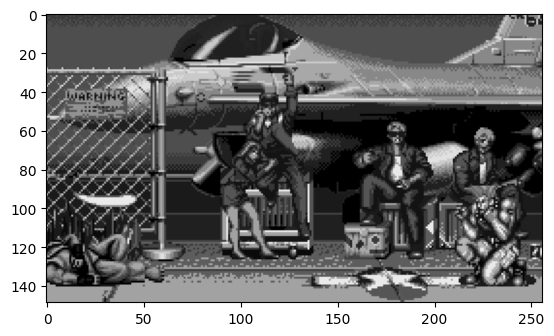

In [9]:
plt.imshow(cv2.cvtColor(obs,cv2.COLOR_BGR2RGB))

# **Hyperparameter tuning:**

Install required libraries for training:
- pip install torch==1.11.0+cu113 torchvision==0.12.0+cu113 torchaudio==0.11.0 --extra-index-url https://download.pytorch.org/whl/cu113
- pip install stable-baselines3[extra]==1.3.0
- pip install optuna==2.10.0

In [4]:
import os
# Importing optimization framework - HPO
import optuna
# PPO algorithm for Reinforcement Learning
from stable_baselines3 import PPO
# Eval policy method for metric calculation
from stable_baselines3.common.evaluation import evaluate_policy
# Import the sb3 monitor for logging
from stable_baselines3.common.monitor import Monitor
# Import the vec wrappers to vectorize and frame stack
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

e:\Projects\StreetFighter\.Fighter\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Setup directories for logs and models
LOG_DIR = './logs/'
OPT_DIR = './opt/'

In [6]:
# Function to return test hyperparamenters - define the objective function
def optimize_ppo(trial):
    return{
        'n_steps':trial.suggest_int('n_steps', 2240, 3200),
        'gamma': trial.suggest_loguniform('gamma', 0.89, 0.99),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-8, 1e-6),
        'clip_range': trial.suggest_uniform('clip_range', 0.3, 0.4),
        'gae_lambda': trial.suggest_uniform('gae_lambda', 0.85, 0.95)
}


In [7]:
# Run a training loop and return mean reward
def optimize_agent(trial):
    try:
        model_params = optimize_ppo(trial)
        
        # Create environment
        env = StreetFighter()
        env = Monitor(env, LOG_DIR)
        env = DummyVecEnv([lambda: env])
        env = VecFrameStack(env, 4, channels_order='last')  
        
        # Create algorithm
        model = PPO('CnnPolicy', env, tensorboard_log=LOG_DIR, verbose=0, **model_params)
        model.learn(total_timesteps=100000)
        
        # Evaluate model
        mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=10)
        env.close()

        SAVE_PATH = os.path.join(OPT_DIR, 'trial_{}_best_model'.format(trial.number))
        model.save(SAVE_PATH)
        
        return mean_reward
    
    except Exception as e:
        print(e)
        return -1000

After Running the trial Switch on tensorboard from terminal to view analytics:
- cd logs
- tensorboard --logdir=.
- http://localhost:6006/#scalars

In [8]:
# Create the experiment
study = optuna.create_study(direction='maximize')
study.optimize(optimize_agent, n_trials=1, n_jobs=1)

[I 2024-04-12 02:41:57,034] A new study created in memory with name: no-name-f7943417-4849-48f0-becf-2680a27b3475
e:\Projects\StreetFighter\.Fighter\lib\site-packages\stable_baselines3\ppo\ppo.py:137: UserWarning: You have specified a mini-batch size of 64, but because the `RolloutBuffer` is of size `n_steps * n_envs = 3097`, after every 48 untruncated mini-batches, there will be a truncated mini-batch of size 25
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=3097 and n_envs=1)
  warnings.warn(
[I 2024-04-12 02:58:30,659] Trial 0 finished with value: 5834.090909 and parameters: {'n_steps': 3097, 'gamma': 0.9781224477155431, 'learning_rate': 5.668590751147218e-08, 'clip_range': 0.36738121849246386, 'gae_lambda': 0.8504348536882476}. Best is trial 0 with value: 5834.090909.


In [9]:
# Select the best Trial
study.best_params

{'n_steps': 2551,
 'gamma': 0.9653540639072693,
 'learning_rate': 4.223964721500403e-07,
 'clip_range': 0.3625977447429773,
 'gae_lambda': 0.8525587102408173}

# **Setup Callback:**

In [ ]:
# Import base callback
from stable_baselines3.common.callbacks import BaseCallback

# Setup Callback function
class TrainAndLoggingCallback(BaseCallback):

    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)
    
    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)
        return True

In [ ]:
# Import base callback
from stable_baselines3.common.callbacks import BaseCallback

# Setup Callback function
class TrainAndLoggingCallback(BaseCallback):

    def __init__(self, env, check_freq, save_path, render_interval=1000, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.env = env  # Store the environment for rendering
        self.check_freq = check_freq
        self.save_path = save_path
        self.render_interval = render_interval
        self.num_timesteps = 0

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        self.num_timesteps += 1

        if self.num_timesteps % self.render_interval == 0:
            self.env.render()  # Render the environment

        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)
        return True

In [ ]:
CHECKPOINT_DIR = './train/Reward_PPO3'

In [ ]:
callback = TrainAndLoggingCallback(check_freq=10000, save_path= CHECKPOINT_DIR)

In [ ]:
callback = TrainAndLoggingCallback(env, check_freq=10000, save_path= CHECKPOINT_DIR)

# **Train the model:**

In [ ]:
env = StreetFighter()
env = Monitor(env, LOG_DIR)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order='last')

In [ ]:
# Pass in the best parameters
model_params = {
    'n_steps': 2560,
    'gamma': 0.9681651918983386,
    'learning_rate': 1.618026331760048e-06,
    'clip_range': 0.3016943860792775,
    'gae_lambda': 0.8538346626803616
}

In [ ]:
model_params

In [ ]:
LOG_DIR= './logs/Reward_PPO3'

In [ ]:
# Create algorithm
model = PPO('CnnPolicy', env, tensorboard_log=LOG_DIR, verbose=0, **model_params, )
model.load(os.path.join(OPT_DIR,'trial_2_best_model.zip'))

In [ ]:
model.learn(total_timesteps=1000000, callback= callback)

In [ ]:
env.close()

# **Test out the Model:**

In [ ]:
model = PPO.load('./train/Trail37/best_model_400000')

In [ ]:
model = PPO.load(os.path.join(OPT_DIR,'trial_37_best_model.zip'))

In [ ]:
env = StreetFighter()
env = Monitor(env, LOG_DIR)
env = DummyVecEnv([lambda: env])
env = VecFrameStack(env, 4, channels_order='last')

In [ ]:
for episode in range(1): 
    obs = env.reset()
    done = False
    total_reward = 0
    while not done: 
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)
        env.render()
        if reward > 0:
            print (reward,action.)
        time.sleep(0.01)
        total_reward += reward
    print('Total Reward for episode {} is {}'.format(total_reward, episode))
    time.sleep(2)